<a href="https://colab.research.google.com/github/i-wanna-stay-at-your-house/-/blob/main/%F0%9F%8E%99%EF%B8%8FPredict_%F0%9F%8E%A4Podcast_Listening%F0%9F%91%82_Time%E2%8C%9A_Copy1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [155]:
df_train = pd.read_csv('/content/train.csv') #훈련
df_test  = pd.read_csv('/content/test.csv') #검증
df_sub = pd.read_csv('/content/sample_submission.csv') #제출 샘플

In [127]:
df_train.info()
#독립변수 12개
#id는 drop함
#listening time minutes가 종속변수
#가정은 host_popularity, episode_length_minutes가 높고, number_of_ads가 낮을수록 종속변수가 크게 나타난다고 생각함
#guest, episode_length가 많이 없으므로 평균 또는 중앙값을 채워넣어야 됨을 1순위, 성능이 너무 안 좋으면 null값을 drop하고 재실행할 계획을 세움

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [7]:
df_train.describe()

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,750000.000000,662907.000000,750000.000000,603970.000000,749999.000000,750000.000000
mean,374999.500000,64.504738,59.859901,52.236449,1.348855,45.437406
std,216506.495284,32.969603,22.873098,28.451241,1.151130,27.138306
min,0.000000,0.000000,1.300000,0.000000,0.000000,0.000000
25%,187499.750000,35.730000,39.410000,28.380000,0.000000,23.178350
50%,374999.500000,63.840000,60.050000,53.580000,1.000000,43.379460
75%,562499.250000,94.070000,79.530000,76.600000,2.000000,64.811580
max,749999.000000,325.240000,119.460000,119.910000,103.910000,119.970000


In [8]:
df_test.head(15)

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,750000,Educational Nuggets,Episode 73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
1,750001,Sound Waves,Episode 23,27.87,Music,71.29,Sunday,Morning,NaN,0.0,Neutral
2,750002,Joke Junction,Episode 11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
3,750003,Comedy Corner,Episode 73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
4,750004,Life Lessons,Episode 50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral
5,750005,Money Matters,Episode 43,34.44,Business,77.18,Sunday,Night,NaN,0.0,Neutral
6,750006,Mystery Matters,Episode 33,116.09,True Crime,27.57,Friday,Night,22.82,1.0,Positive
7,750007,Gadget Geek,Episode 24,54.59,Technology,94.86,Tuesday,Morning,94.76,1.0,Neutral
8,750008,Home & Living,Episode 87,92.69,Lifestyle,75.22,Friday,Night,72.63,0.0,Neutral
9,750009,True Crime Stories,Episode 76,100.65,True Crime,27.66,Tuesday,Evening,NaN,1.0,Negative


In [9]:
df_sub.head()

,id,Listening_Time_minutes
0,750000,45.437
1,750001,45.437
2,750002,45.437
3,750003,45.437
4,750004,45.437


In [156]:
df_train.drop(columns=['id'], inplace=True)
df_test.drop(columns=['id'], inplace=True)

#id 칼럼 드롭

In [38]:
df_train.isnull().sum()

,0
id,0
Podcast_Name,0
Episode_Title,0
Episode_Length_minutes,87093
Genre,0
Host_Popularity_percentage,0
Publication_Day,0
Publication_Time,0
Guest_Popularity_percentage,146030
Number_of_Ads,1


In [13]:
df_test.isnull().sum()

,0
Podcast_Name,0
Episode_Title,0
Episode_Length_minutes,28736
Genre,0
Host_Popularity_percentage,0
Publication_Day,0
Publication_Time,0
Guest_Popularity_percentage,48832
Number_of_Ads,0
Episode_Sentiment,0


In [15]:
df_train.dtypes

df_train["Number_of_Ads"].value_counts()

#ads가 0~3개가 가장 많고 그 이외에는 이상치로 판단 됨. 자세한건 시각화쪽에서

,count
Number_of_Ads,
0.00,217592
1.00,214069
3.00,160173
2.00,158156
103.25,2
53.37,1
103.91,1
103.00,1
53.42,1


In [157]:
common_cols = df_train.columns.intersection(df_test.columns)

numerical_cols = df_train[common_cols].select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df_train[common_cols].select_dtypes(include=['object']).columns

df_train[numerical_cols] = df_train[numerical_cols].fillna(df_train[numerical_cols].median())
df_test[numerical_cols] = df_test[numerical_cols].fillna(df_train[numerical_cols].median())
df_train[categorical_cols] = df_train[categorical_cols].apply(lambda x: x.fillna(x.mode()[0]))
df_test[categorical_cols] = df_test[categorical_cols].apply(lambda x: x.fillna(df_train[x.name].mode()[0]))

#수치형, 범주형으로 변수를 나눠 수치형 변수의 null값(Episode_Length_minutes, Guest_Popularity_percentage, Number_of_Ads)을 median으로 채우고 범주형 null값 제외
#성능은 mean으로 채웠을 때보다 median을 채웠을 때 더 높게 나옴.

In [158]:
#아래 그래프에서 episode_length_minutes을 시각화하니까 300넘는 값이 1개 발견됨, 근데 listening time이랑 비례하지도 않고..이상치로 판단되어 삭제함
df_train = df_train[~(df_train["Episode_Length_minutes"] > 150)]
df_train.isnull().sum()

,0
Podcast_Name,0
Episode_Title,0
Episode_Length_minutes,0
Genre,0
Host_Popularity_percentage,0
Publication_Day,0
Publication_Time,0
Guest_Popularity_percentage,0
Number_of_Ads,0
Episode_Sentiment,0


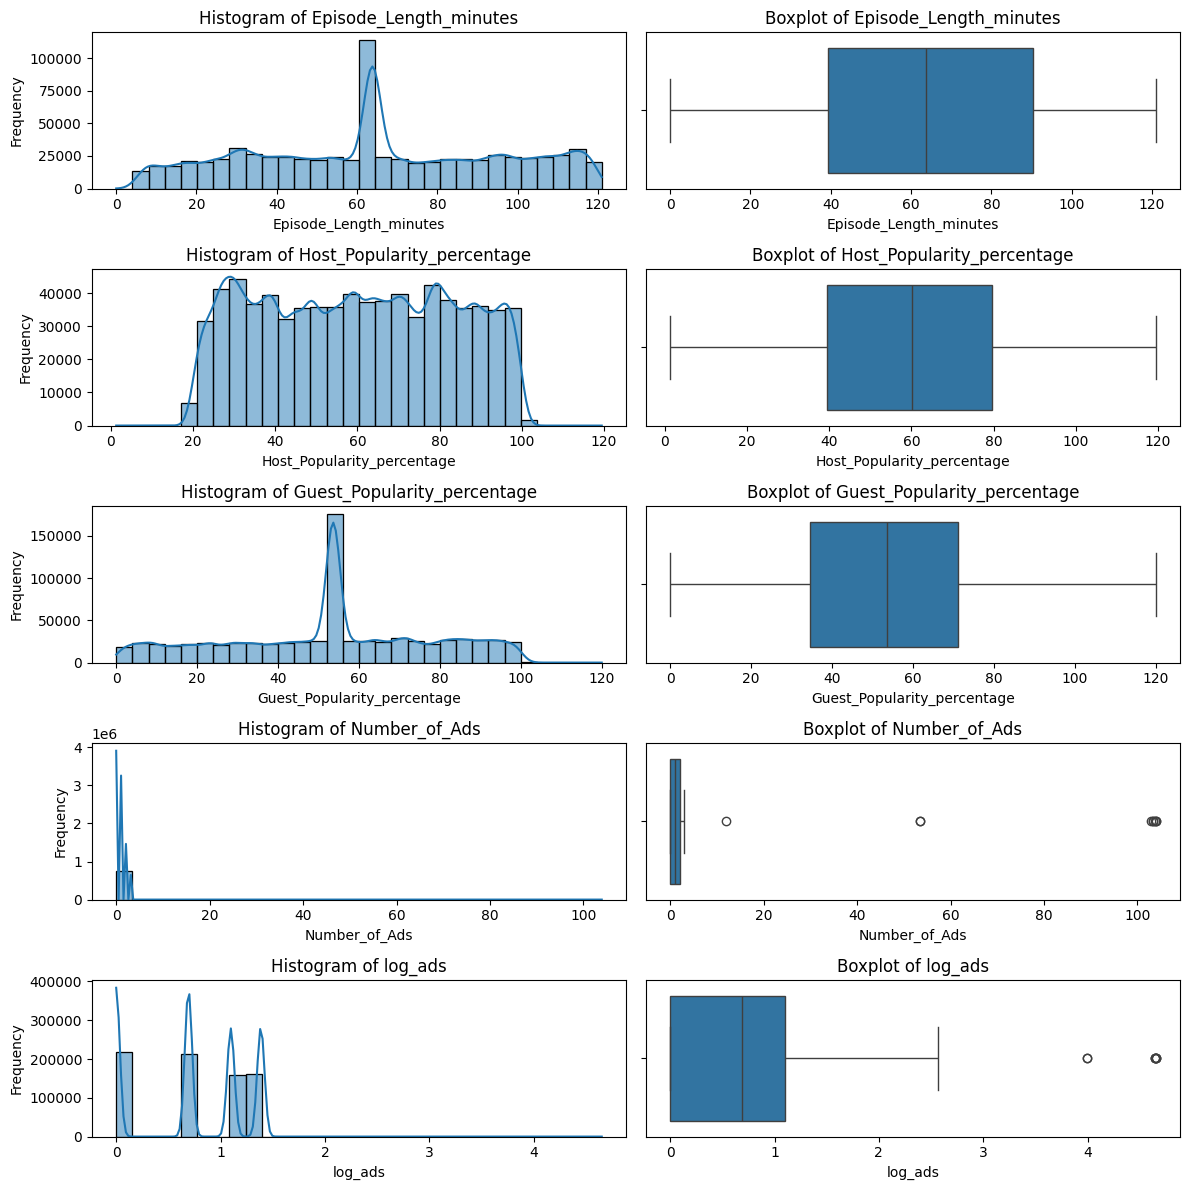

In [160]:
# 로그변수 추가
df_train['log_ads'] = np.log1p(df_train['Number_of_Ads'])

# 대상 변수 리스트
cols = [
    "Episode_Length_minutes",
    "Host_Popularity_percentage",
    "Guest_Popularity_percentage",
    "Number_of_Ads",
    "log_ads"
]

# 전체 subplot: 4행 2열 (히스토그램 + 박스플롯 한 쌍)
plt.figure(figsize=(12, 12))

for i, col in enumerate(cols):
    # 히스토그램 (왼쪽)
    plt.subplot(len(cols), 2, 2*i + 1)
    sns.histplot(df_train[col], bins=30, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    # 박스플롯 (오른쪽)
    plt.subplot(len(cols), 2, 2*i + 2)
    sns.boxplot(x=df_train[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

#Ads 변수는 가시성이 떨어져 로그를 씌워 재확인
#log_ads에서 max값이 2~3 사이로 확인됨. 실제로도 50~100개에서 ads값이 있는 행이 있는데, 현실적으로 불가능하므로 3개를 초과하면 뺐음
#median으로 채운 변수, 안 채운 변수 모두 거의 정규분포로 확인됨

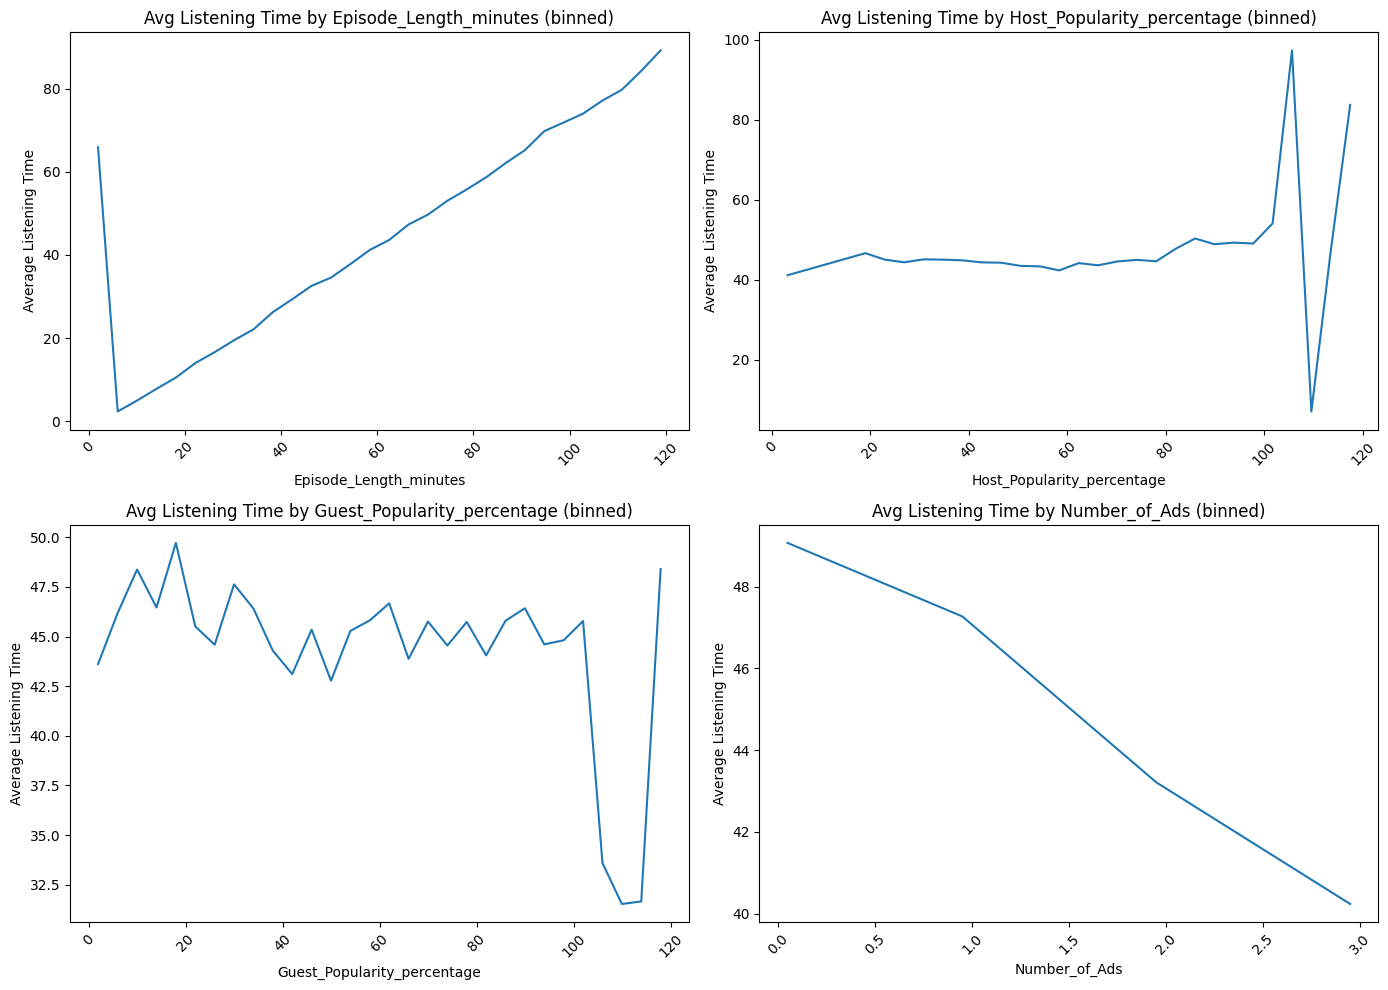

In [161]:
cols = [
    "Episode_Length_minutes",
    "Host_Popularity_percentage",
    "Guest_Popularity_percentage",
    'Number_of_Ads'
]

plt.figure(figsize=(14, 10))

for i, col in enumerate(cols):
    df_bin = df_train[[col, 'Listening_Time_minutes']].copy()

    # ✅ Number_of_Ads일 경우 0~3만 필터링
    if col == "Number_of_Ads":
        df_bin = df_bin[df_bin[col] <= 3]

    # 30개 구간으로 binning
    df_bin['bin'] = pd.cut(df_bin[col], bins=30)

    # 구간별 중앙값 계산
    grouped = df_bin.groupby('bin', observed=True)['Listening_Time_minutes'].mean().reset_index()
    grouped['bin_center'] = grouped['bin'].apply(lambda x: x.mid)

    # 그래프
    plt.subplot(2, 2, i + 1)
    sns.lineplot(x=grouped['bin_center'], y=grouped['Listening_Time_minutes'])
    plt.title(f"Avg Listening Time by {col} (binned)")
    plt.ylabel("Average Listening Time")
    plt.xlabel(f"{col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#episode length minutes이 0~10에서는 반비례하다가 10부터 max값까지 쭉 비례함. 팟캐스트 특성상 10분은 넘기는게 좋은 것으로 나옴. 보통 틀어놓고 작업하거나
#다른거 하면서 틀어놓거나 하니까 10분 미만은 잘 안 튼다고 생각됨.
#host, guest popularity는 0~100까지는 큰 상관관계가 없다가 100~120 구간에서 크게 요동침. 왜일까..
#ads가 늘어날수록 listening time과 반비례함. 어찌보면 일반적

In [162]:
#Number_of_Ads가 0~3이 아닌 행 제거
df_filtered = df_train[df_train['Number_of_Ads'].between(0, 3)]

In [163]:
# Host 또는 Guest Popularity가 100 이상인 행 필터링
high_popularity = df_train[
    (df_train["Host_Popularity_percentage"] > 100) |
    (df_train["Guest_Popularity_percentage"] > 100)
]

# 행 수 카운트
count = high_popularity.shape[0]

print(f"Host 또는 Guest Popularity가 100 이상인 행 수: {count}")

#host, guest popularity가 100이상일때 생기는 이상치, 갑자기 급락, 혹은 변동성 증가는 이상치 때문일 가능성이 커짐
#개수가 너무 적기 때문임
#따라서 그냥 빼버리는게 어떤지..그럼 상관관계가 크게 없는건가?
#전체 데이터가 75만 건인데, 100 초과인 건 단 44개 → 0.0058%

Host 또는 Guest Popularity가 100 이상인 행 수: 44


In [164]:
df_train = df_train[
    (df_train["Host_Popularity_percentage"] <= 100) &
    (df_train["Guest_Popularity_percentage"] <= 100)
]

#빼버림

In [165]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 749955 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Podcast_Name                 749955 non-null  object 
 1   Episode_Title                749955 non-null  object 
 2   Episode_Length_minutes       749955 non-null  float64
 3   Genre                        749955 non-null  object 
 4   Host_Popularity_percentage   749955 non-null  float64
 5   Publication_Day              749955 non-null  object 
 6   Publication_Time             749955 non-null  object 
 7   Guest_Popularity_percentage  749955 non-null  float64
 8   Number_of_Ads                749955 non-null  float64
 9   Episode_Sentiment            749955 non-null  object 
 10  Listening_Time_minutes       749955 non-null  float64
 11  log_ads                      749955 non-null  float64
dtypes: float64(6), object(6)
memory usage: 74.4+ MB


<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">🎇🌭Regression Analysis♒🌊</h1>  
     
</div>

In [166]:
y = df_train['Listening_Time_minutes']

In [167]:
X = df_train
X_test = df_test

#검증 데이터가 이미 존재하므로 굳이 split 하지 않았음

In [168]:
X.head()
X.drop(columns=['Listening_Time_minutes'], inplace=True)
X.drop(columns=['log_ads'], inplace=True)
X.head()

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,Mystery Matters,Episode 98,63.84,True Crime,74.81,Thursday,Night,53.58,0.0,Positive
1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative
2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative
3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive
4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral


In [57]:
!pip uninstall -y numpy scikit-learn category_encoders xgboost lightgbm

!pip install numpy==1.23.5
!pip install scikit-learn==1.1.3
!pip install category_encoders==2.6.1
!pip install xgboost==1.7.6
!pip install lightgbm==3.3.5

Found existing installation: numpy 1.23.5
Uninstalling numpy-1.23.5:
  Successfully uninstalled numpy-1.23.5
Found existing installation: scikit-learn 1.1.3
Uninstalling scikit-learn-1.1.3:
  Successfully uninstalled scikit-learn-1.1.3
Found existing installation: category-encoders 2.6.1
Uninstalling category-encoders-2.6.1:
  Successfully uninstalled category-encoders-2.6.1
Found existing installation: xgboost 1.7.6
Uninstalling xgboost-1.7.6:
  Successfully uninstalled xgboost-1.7.6
Found existing installation: lightgbm 3.3.5
Uninstalling lightgbm-3.3.5:
  Successfully uninstalled lightgbm-3.3.5
  Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.7.19 requir

  Using cached scikit_learn-1.1.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (10 kB)
Using cached scikit_learn-1.1.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (32.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imbalanced-learn 0.13.0 requires numpy<3,>=1.24.3, but you have numpy 1.23.5 which is incompatible.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.1.3 which is incompatible.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, but you have scikit-learn 1.1.3 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.1.3 which is incompatible.


  Using cached category_encoders-2.6.1-py2.py3-none-any.whl.metadata (7.9 kB)
Using cached category_encoders-2.6.1-py2.py3-none-any.whl (81 kB)


  Using cached xgboost-1.7.6-py3-none-manylinux2014_x86_64.whl.metadata (1.9 kB)
Using cached xgboost-1.7.6-py3-none-manylinux2014_x86_64.whl (200.3 MB)


  Using cached lightgbm-3.3.5-py3-none-manylinux1_x86_64.whl.metadata (15 kB)
Using cached lightgbm-3.3.5-py3-none-manylinux1_x86_64.whl (2.0 MB)


In [59]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
import gc
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor, Pool
import xgboost as xgb

#사용한 머신러닝 알고리즘


In [169]:
# 📦 라이브러리 불러오기
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from category_encoders import TargetEncoder
from xgboost import XGBRegressor

# ✅ RMSE 함수 정의
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ✅ 타겟 인코딩 대상 컬럼
encoded_columns = ['Podcast_Name', 'Genre', 'Episode_Title', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']

# ✅ 모든 범주형 컬럼을 category 타입으로 변환 (문자열 순서 유지)
for col in encoded_columns:
    X[col] = X[col].astype('category')

# ✅ 원래 범주 복원용 매핑
original_values_map = {col: dict(enumerate(X[col].cat.categories)) for col in encoded_columns}

# ✅ 타겟 인코딩
encoder = TargetEncoder(cols=encoded_columns, handle_unknown='ignore')
encoder.fit(X[encoded_columns], y)

# ✅ 매핑 출력 (NaN 제거 포함)
for col in encoded_columns:
    print(f"\n🔹 {col} 타겟 인코딩 매핑:")

    mapping = encoder.mapping[col]

    # Series → DataFrame 변환
    if isinstance(mapping, pd.Series):
        mapping = mapping.reset_index()
        mapping.columns = ['Original_Value', 'Encoded_Value']
    else:
        mapping = mapping.rename(columns={col: 'Original_Value', 'mean': 'Encoded_Value'})

    # 원래 이름으로 복원
    if col in original_values_map:
        mapping['Original_Value'] = mapping['Original_Value'].map(original_values_map[col])

    # ✅ NaN 제거
    mapping = mapping.dropna(subset=['Original_Value'])

    print(mapping.head(10))

/usr/local/lib/python3.11/dist-packages/category_encoders/ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)
/usr/local/lib/python3.11/dist-packages/category_encoders/ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa


🔹 Podcast_Name 타겟 인코딩 매핑:
      Original_Value  Encoded_Value
0        Brain Boost      46.019176
1    Business Briefs      42.632336
2  Business Insights      47.047780
3      Comedy Corner      44.769237
4   Crime Chronicles      46.838872
5     Criminal Minds      45.619947
6    Current Affairs      43.548438
7       Daily Digest      42.704065
8  Detective Diaries      45.697657
9     Digital Digest      46.091767

🔹 Genre 타겟 인코딩 매핑:
  Original_Value  Encoded_Value
0         Comedy      46.042606
1      Education      44.424888
2         Health      45.736997
3      Lifestyle      45.634622
4          Music      45.740385
5           News      44.406158
6         Sports      46.578565
7     Technology      44.935712
8     True Crime      45.538447

🔹 Episode_Title 타겟 인코딩 매핑:
  Original_Value  Encoded_Value
0     Episode 10      41.311952
1    Episode 100      46.162666
2     Episode 11      44.577808
3     Episode 12      50.551025
4     Episode 13      45.055444
5     Episode 14 

/usr/local/lib/python3.11/dist-packages/category_encoders/ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)


<ipython-input-122-7af394896bdb>:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=X, x=col, y=y, estimator=np.mean, ci='sd')
<ipython-input-122-7af394896bdb>:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=X, x=col, y=y, estimator=np.mean, ci='sd')
<ipython-input-122-7af394896bdb>:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=X, x=col, y=y, estimator=np.mean, ci='sd')
<ipython-input-122-7af394896bdb>:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=X, x=col, y=y, estimator=np.mean, ci='sd')
<ipython-input-122-7af394896bdb>:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=X, x=col, y=y, estimator=np.mean, ci='sd')
<ipython-input-122-7af394896bdb>:13: Fut

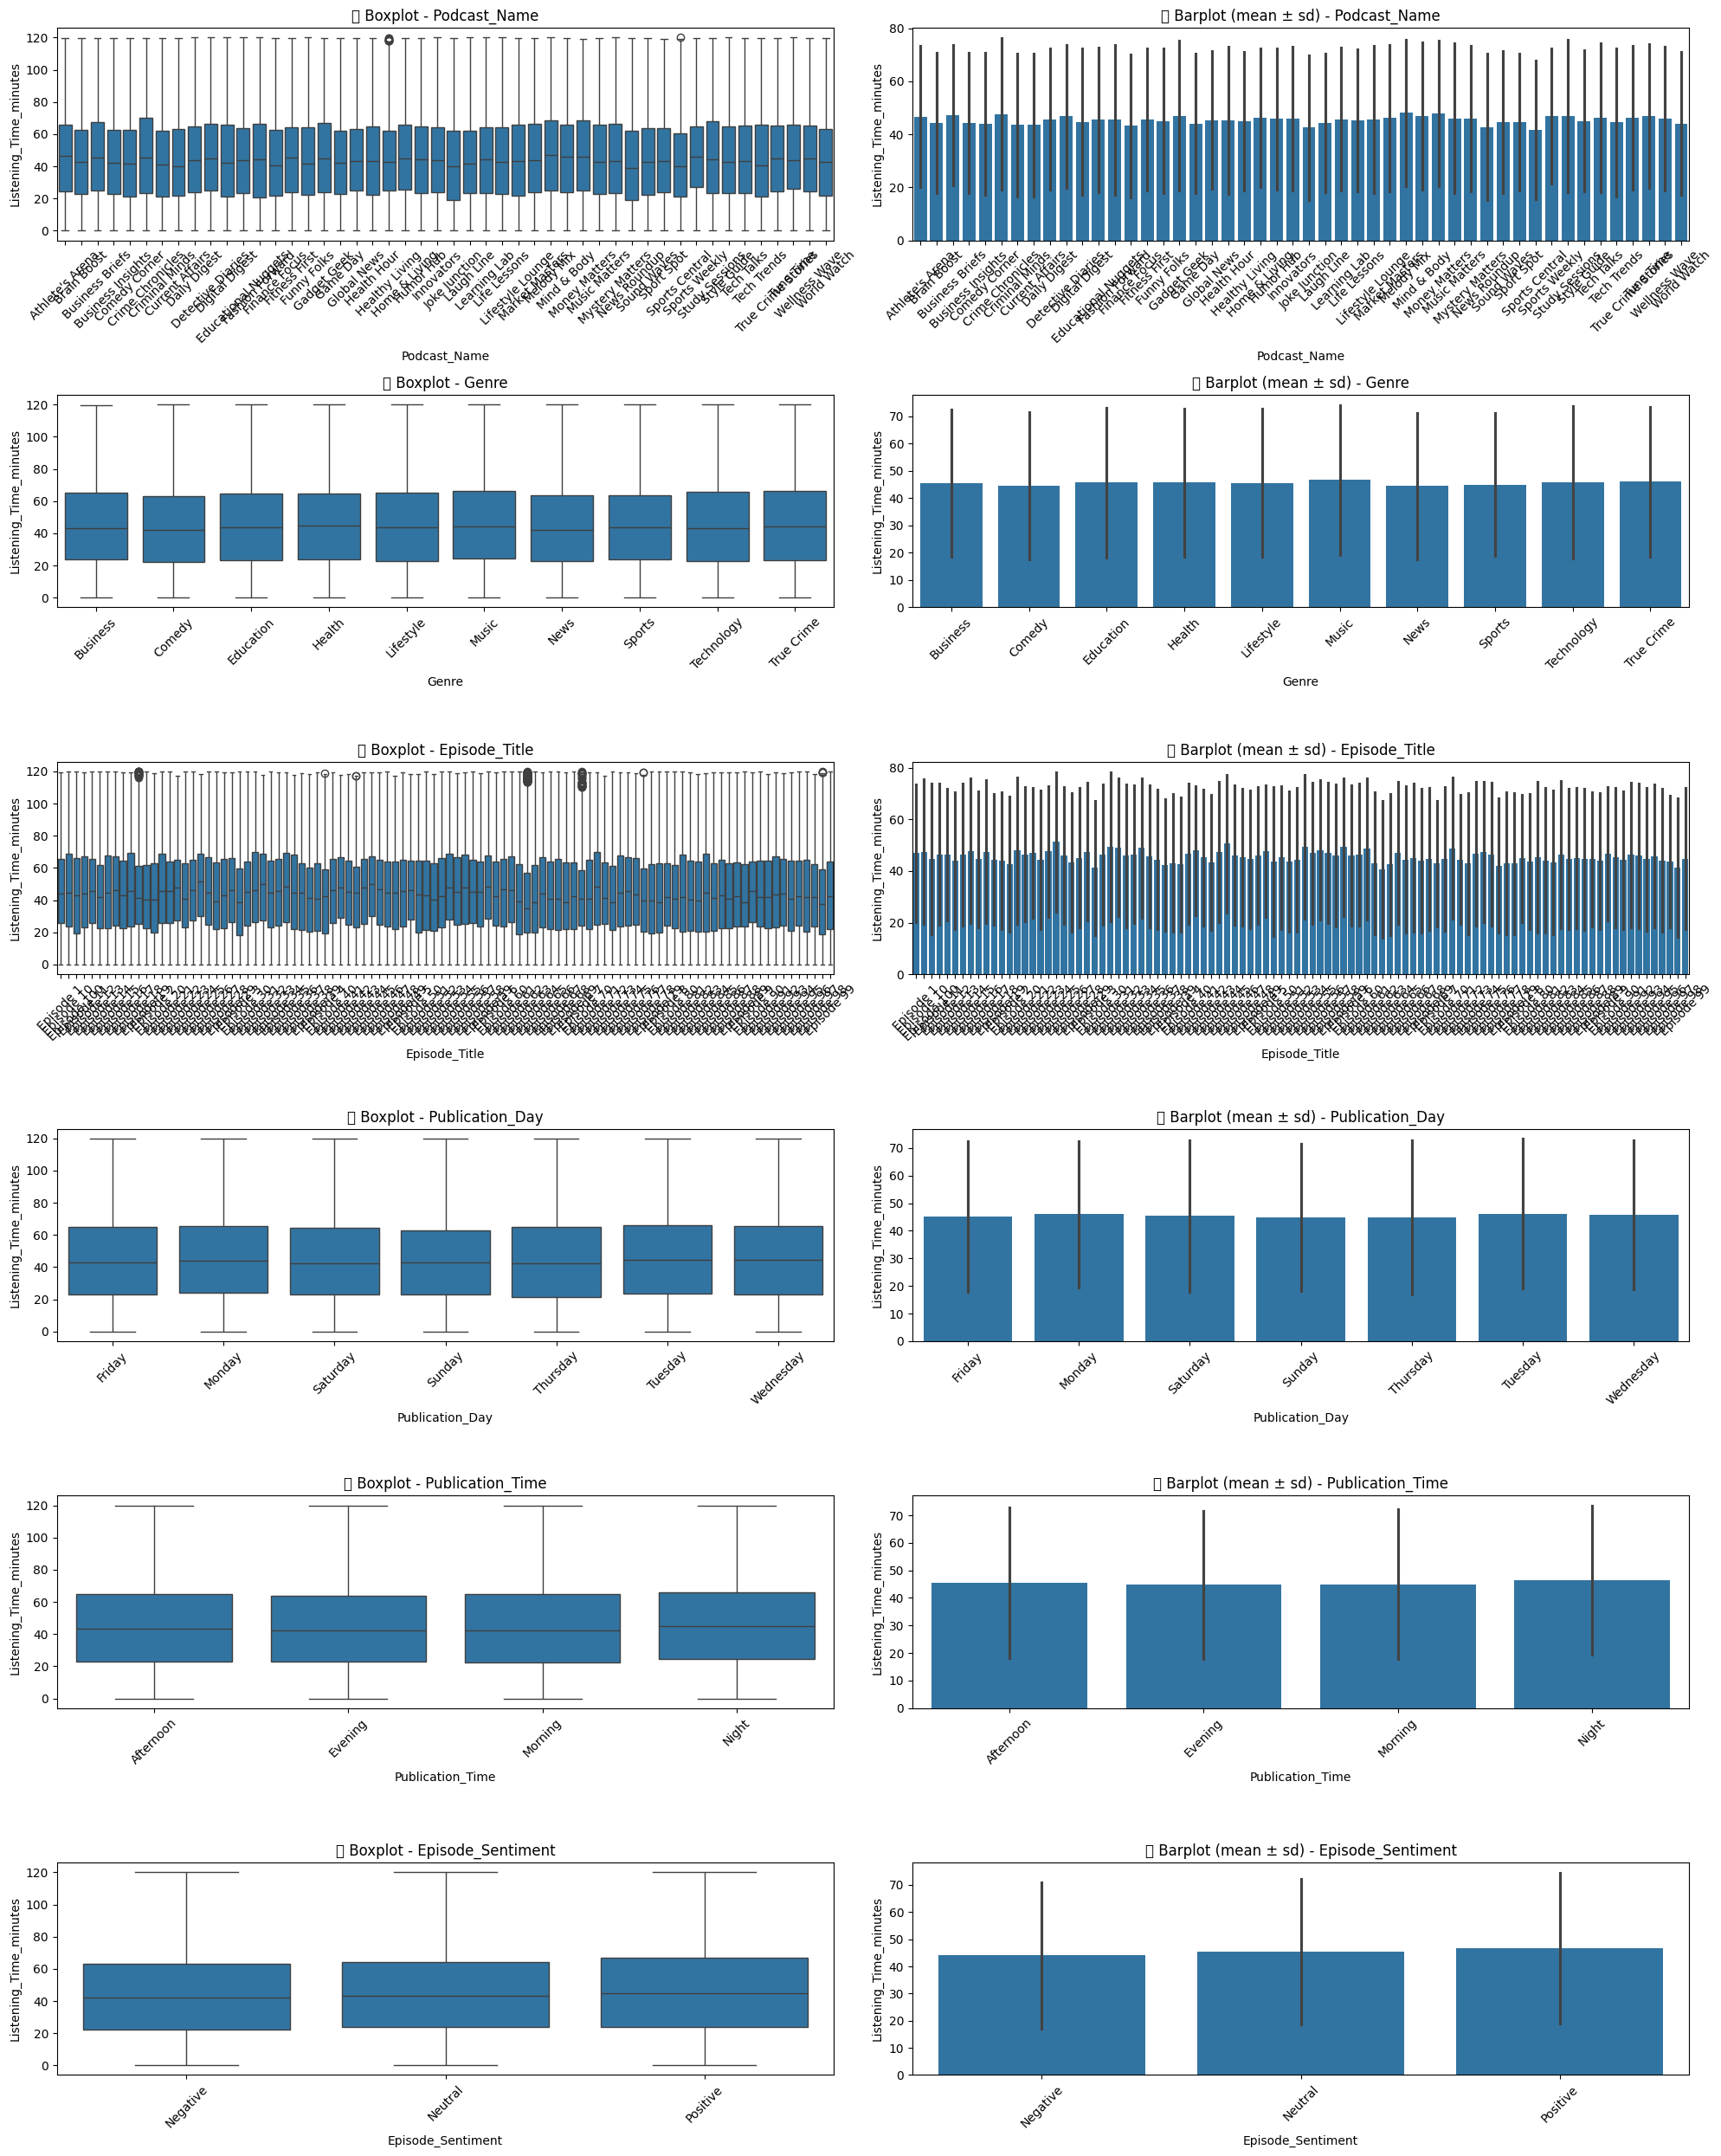

In [122]:
# 타겟 인코딩 전에 쓰였던 원본 category 컬럼
encoded_columns = ['Podcast_Name', 'Genre', 'Episode_Title', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']

plt.figure(figsize=(20, 25))

for i, col in enumerate(encoded_columns):
    plt.subplot(len(encoded_columns), 2, 2 * i + 1)
    sns.boxplot(data=X, x=col, y=y)
    plt.title(f"📦 Boxplot - {col}")
    plt.xticks(rotation=45)

    plt.subplot(len(encoded_columns), 2, 2 * i + 2)
    sns.barplot(data=X, x=col, y=y, estimator=np.mean, ci='sd')
    plt.title(f"📊 Barplot (mean ± sd) - {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#결론: Podcast_Name은 약한 영향만 있을 가능성.
#→ 타겟 인코딩보단 삭제하거나 상위 인기만 활용 가능성 고려
#이거 맞나? 아닌 것 같은데

#rue Crime > Comedy > Health > Business 순서로 약간 높은 평균
#타겟 인코딩 하는게 좋음

#시간대는 영향력이 있음
#→ Afternoon에 발행된 콘텐츠가 오래 들음

#결론: 감정 분위기도 청취 시간에 영향을 줌
#→ 예: 중립적인 에피소드가 더 오래 들음

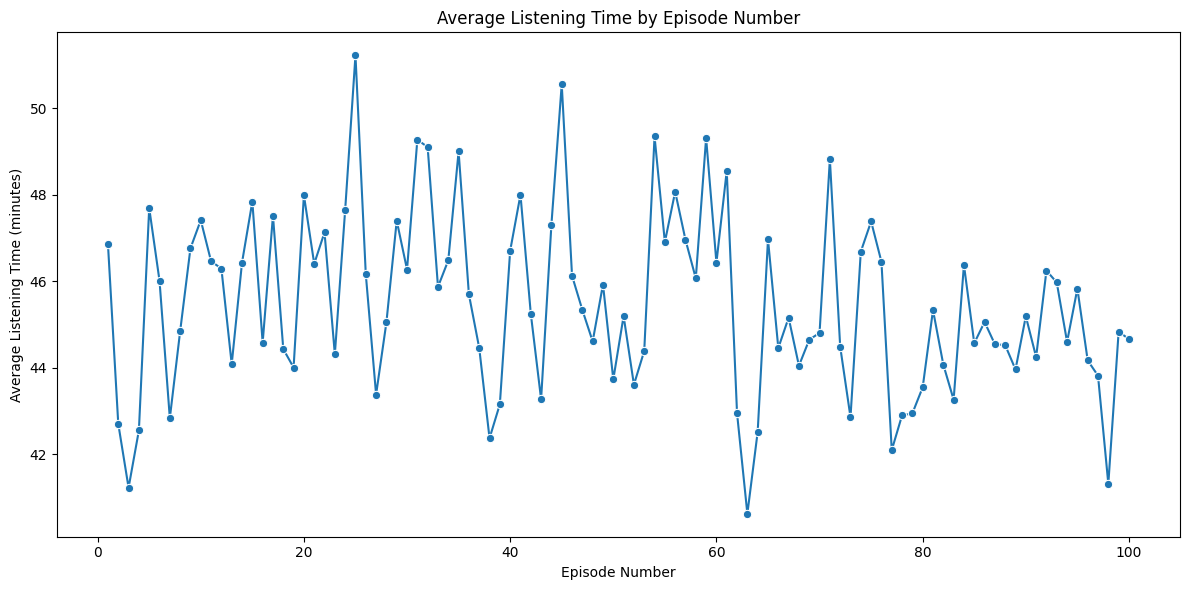

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,Mystery Matters,Episode 98,63.84,True Crime,74.81,Thursday,Night,53.58,0.0,Positive
1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative
2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative
3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive
4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral
...,...,...,...,...,...,...,...,...,...,...
749995,Learning Lab,Episode 25,75.66,Education,69.36,Saturday,Morning,53.58,0.0,Negative
749996,Business Briefs,Episode 21,75.75,Business,35.21,Saturday,Night,53.58,2.0,Neutral
749997,Lifestyle Lounge,Episode 51,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative
749998,Style Guide,Episode 47,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative


In [170]:
# 1. Episode Number 추출
X['Episode_Number'] = X['Episode_Title'].str.extract(r'(\d+)').astype(int)

# 2. 에피소드 번호별 평균 청취 시간 구하기
grouped = X.copy()
grouped['Listening_Time_minutes'] = y
grouped = grouped.groupby('Episode_Number')['Listening_Time_minutes'].mean().reset_index()

# 3. 꺾은선 그래프 시각화
plt.figure(figsize=(12, 6))
sns.lineplot(data=grouped, x='Episode_Number', y='Listening_Time_minutes', marker='o')
plt.title("Average Listening Time by Episode Number")
plt.xlabel("Episode Number")
plt.ylabel("Average Listening Time (minutes)")
plt.tight_layout()
plt.show()

#episode 길이랑 비례하지 않음. 굳이 피쳐 엔지니어링 안 해도 될 듯

X.drop(columns=['Episode_Number'], inplace=True)
X

In [172]:
# ✅ 타겟 인코딩 대상 컬럼
encoded_columns = ['Podcast_Name', 'Genre', 'Episode_Title', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']

# ✅ 문자열 → category로 강제 변환 (범주 보존)
for col in encoded_columns:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# ✅ 원래 범주 복원용 매핑 저장 (선택)
original_values_map = {col: dict(enumerate(X[col].cat.categories)) for col in encoded_columns}

# ✅ TargetEncoder 학습 + 적용
encoder = TargetEncoder(cols=encoded_columns, handle_unknown='ignore')
X[encoded_columns] = encoder.fit_transform(X[encoded_columns], y)
X_test[encoded_columns] = encoder.transform(X_test[encoded_columns])


# ✅ XGBoost 하이퍼파라미터
xgb_params = {
    'n_estimators': 565,
    'max_depth': 14,
    'learning_rate': 0.04222221,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'tree_method': 'hist',   # CPU 사용 시 'hist'로 바꿔도 됨
    'n_jobs': -1
}

# ✅ 교차검증 설정
n_splits = 3
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
scores = []
test_preds = np.zeros(len(X_test))

# ✅ 학습 + 예측 루프
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"Training fold {fold + 1}/{n_splits}...")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBRegressor(**xgb_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=100
    )

    val_pred = model.predict(X_val)
    score = rmse(y_val, val_pred)
    scores.append(score)

    test_preds += model.predict(X_test) / n_splits
    print(f"Fold {fold + 1} RMSE: {score:.4f}")

# ✅ 성능 요약
print(f'\nOptimized Cross-validated RMSE score: {np.mean(scores):.3f} ± {np.std(scores):.3f}')
print(f'Max RMSE score: {np.max(scores):.3f}')
print(f'Min RMSE score: {np.min(scores):.3f}')

/usr/local/lib/python3.11/dist-packages/category_encoders/ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)
/usr/local/lib/python3.11/dist-packages/category_encoders/ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

Training fold 1/3...
[0]	validation_0-rmse:50.38195
[100]	validation_0-rmse:12.91821
[200]	validation_0-rmse:12.78488
[300]	validation_0-rmse:12.74037
[400]	validation_0-rmse:12.72402
[500]	validation_0-rmse:12.71653
[564]	validation_0-rmse:12.71386
Fold 1 RMSE: 12.7139
Training fold 2/3...
[0]	validation_0-rmse:50.48063
[100]	validation_0-rmse:12.97517
[200]	validation_0-rmse:12.84562
[300]	validation_0-rmse:12.80742
[400]	validation_0-rmse:12.78582
[500]	validation_0-rmse:12.77992
[564]	validation_0-rmse:12.77835
Fold 2 RMSE: 12.7783
Training fold 3/3...
[0]	validation_0-rmse:50.41170
[100]	validation_0-rmse:12.93826
[200]	validation_0-rmse:12.80817
[300]	validation_0-rmse:12.76724
[400]	validation_0-rmse:12.75153
[500]	validation_0-rmse:12.74589
[564]	validation_0-rmse:12.74439
Fold 3 RMSE: 12.7444

Optimized Cross-validated RMSE score: 12.746 ± 0.026
Max RMSE score: 12.778
Min RMSE score: 12.714


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# ✅ RMSE 정의
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ✅ 사용할 모델과 하이퍼파라미터 정의
models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42),
    "HistGB": HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=7, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=7, random_state=42, n_jobs=-1)
}

# ✅ 교차검증 설정
n_splits = 3
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# ✅ 모델별 학습 및 평가
for name, model in models.items():
    print(f"\n📌 Training {name}...")
    scores = []
    test_preds = np.zeros(len(X_test))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"  Fold {fold + 1}/{n_splits}")
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        score = rmse(y_val, val_pred)
        scores.append(score)

        test_preds += model.predict(X_test) / n_splits
        print(f"    Fold {fold + 1} RMSE: {score:.4f}")

    print(f"✅ {name} CV RMSE: {np.mean(scores):.3f} ± {np.std(scores):.3f}")



📌 Training RandomForest...
  Fold 1/3
    Fold 1 RMSE: 12.9486
  Fold 2/3
    Fold 2 RMSE: 12.9971
  Fold 3/3


<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">🎇🌭Plots from results for XGboost♒🌊</h1>  
     
</div>

<ipython-input-173-6d085af8f9cf>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis", ax=axes[0, 0])


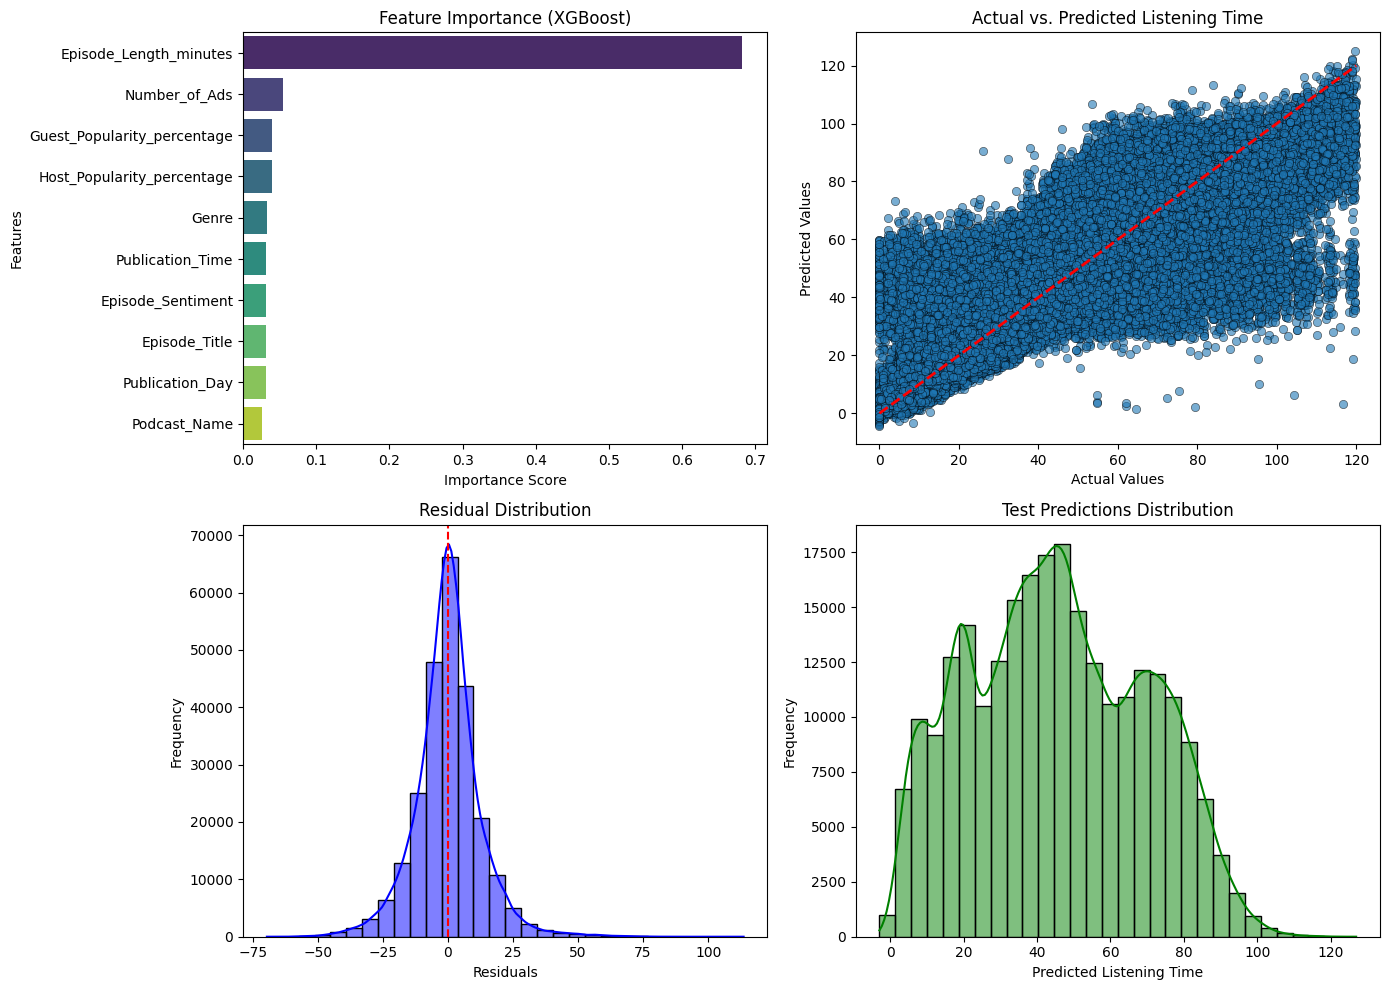

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

feature_importance = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis", ax=axes[0, 0])
axes[0, 0].set_title("Feature Importance (XGBoost)")
axes[0, 0].set_xlabel("Importance Score")
axes[0, 0].set_ylabel("Features")

sns.scatterplot(x=y_val, y=val_pred, alpha=0.6, edgecolors="k", ax=axes[0, 1])
axes[0, 1].plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], '--r', linewidth=2)
axes[0, 1].set_title("Actual vs. Predicted Listening Time")
axes[0, 1].set_xlabel("Actual Values")
axes[0, 1].set_ylabel("Predicted Values")

residuals = y_val - val_pred
sns.histplot(residuals, bins=30, kde=True, color='blue', ax=axes[1, 0])
axes[1, 0].axvline(0, color='red', linestyle='--')
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].set_xlabel("Residuals")
axes[1, 0].set_ylabel("Frequency")

sns.histplot(test_preds, bins=30, kde=True, color='green', ax=axes[1, 1])
axes[1, 1].set_title("Test Predictions Distribution")
axes[1, 1].set_xlabel("Predicted Listening Time")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


#episode_length_minutes가 피쳐 중요도에서 압도적으로 중요함. 근데 너무 중요한데, 이렇게 해도 되나? 거의 70%임
#그 뒤로는 ads 등이 있음
#회귀선 보면 그래도 예측이 맞긴 함
#잔차, 예측(40~60이 중앙값즈음) 모두 정규분포를 따름

In [28]:

df_sub.head()

,id,Listening_Time_minutes
0,750000,45.437
1,750001,45.437
2,750002,45.437
3,750003,45.437
4,750004,45.437


In [174]:
df_sub['Listening_Time_minutes'] = test_preds

In [175]:
df_sub.to_csv('submission-2.csv', index=False)
#이거로 캐글에 제출하니까 점수 12.52 나옴
#이는 실제값에 +-값으로 listening time이 0~119임을 감안하면 괜찮은 점수라고 고려됨

In [176]:
df_sub.head()

,id,Listening_Time_minutes
0,750000,51.396839
1,750001,19.813312
2,750002,51.271807
3,750003,76.251656
4,750004,45.357196


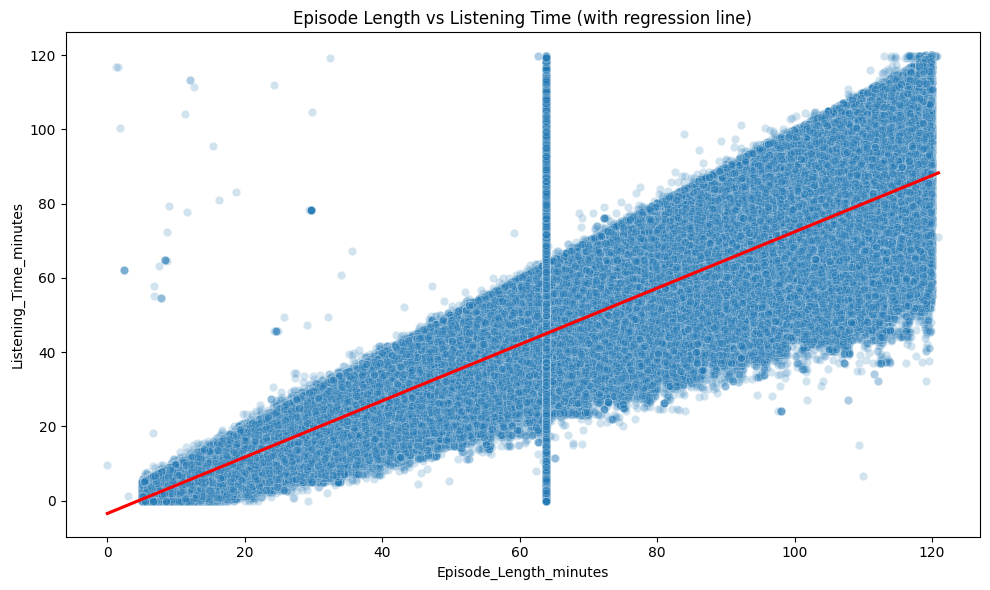

In [180]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X['Episode_Length_minutes'], y=y, alpha=0.2)
sns.regplot(x=X['Episode_Length_minutes'], y=y, scatter=False, color='red')

plt.title("Episode Length vs Listening Time (with regression line)")
plt.xlabel("Episode_Length_minutes")
plt.ylabel("Listening_Time_minutes")
plt.tight_layout()
plt.show()

#실제와 예측의 회귀선 + 산점도